In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('2026_07_15_LED/C1_0/C1_4.CSV')
df = df.rename(columns={'in s': 'time_s', 'C1 in V': 'signal_v'})
#compute the average of the signal
avg=df['signal_v'].mean()
peakidx = df['signal_v'].idxmax()
peaktime = df.loc[peakidx, 'time_s']


Peak ends at: 0.039998052
Peak starts at: 0.0399979128


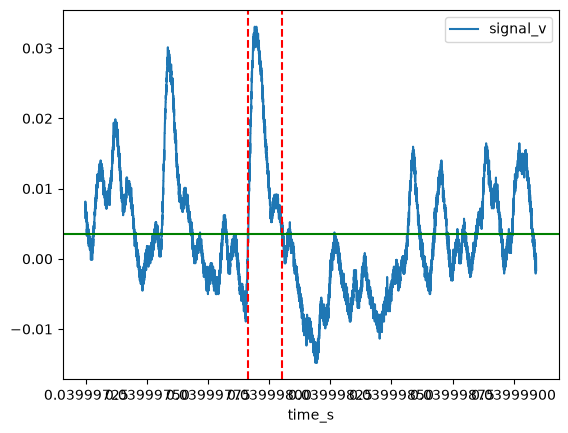

In [3]:
#find the peak of the signal
peak = df['signal_v'].max()
peak_time = df.loc[df['signal_v'] == peak, 'time_s'].iloc[0]
total_avg = df['signal_v'].mean() #abritrarly selected baseline

#search the point where the signal reaches the total_avg after the maximum peak
post_peak_df = df[(df['time_s'] >= peak_time) & (df['signal_v'] <= total_avg)]
if not post_peak_df.empty:
    #get the first point after the peak that drops to baseline
    peak_end = post_peak_df.iloc[0]
    print(f"Peak ends at: {peak_end['time_s']}")
else:
    print("Signal does not drop back to baseline after the peak.")

#do the same for the pre peak point earlier in time
pre_peak_df = df[(df['time_s'] <= peak_time) & (df['signal_v'] <= total_avg)]

if not pre_peak_df.empty:
    # get the last point before the peak that was at baseline
    peak_start = pre_peak_df.iloc[-1]
    print(f"Peak starts at: {peak_start['time_s']}")
else:
    print("Signal was never at baseline before the peak.")


#plot the signal
fig = df.plot(x= 'time_s', y='signal_v')
fig.ticklabel_format(axis='x', style='sci', useOffset=False)
fig.axvline(peak_start['time_s'], color='r', linestyle='--')
fig.axvline(peak_end['time_s'], color='r', linestyle='--')
fig.axhline(y=avg, color='g', linestyle='-', label='Average Signal')
plt.show()


In [4]:
#create a mask that removes the signal
mask = (df['time_s'] < peak_start['time_s']) | (df['time_s'] > peak_end['time_s'])

#call it background
background_df = df[mask]
background_df = background_df.rename(columns={'signal_v': 'bkg_v'})

#save the rest of the data as signal
signal_df = df[~mask]

#average the background signal

background_avg = background_df['bkg_v'].mean()

#compute one sigma deviation of the background_avg
sigma = background_df['bkg_v'].std()


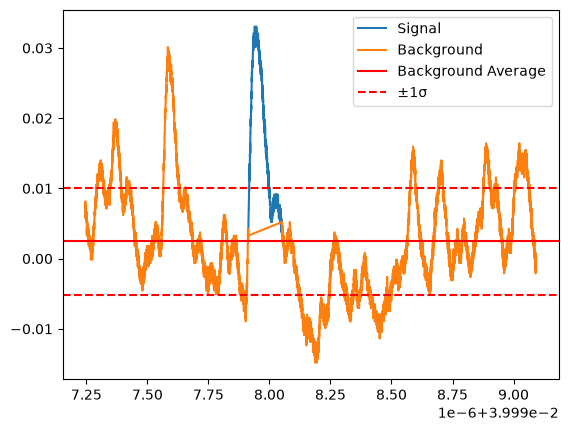

In [5]:
#plot signal, background and sigma ranges

plt.plot(signal_df['time_s'], signal_df['signal_v'], label='Signal')
plt.plot(background_df['time_s'], background_df['bkg_v'], label='Background')
plt.axhline(y=background_avg, color='r', linestyle='-', label='Background Average')
plt.axhline(y=background_avg + sigma, color='r', linestyle='--', label='±1σ')
plt.axhline(y=background_avg - sigma, color='r', linestyle='--')

plt.legend()
plt.show()


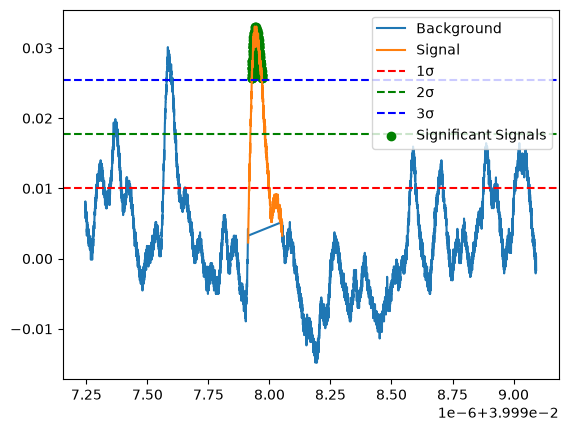

In [6]:
#check where signal meets background + 3 sigma
significant_signals = (signal_df['signal_v'] > background_avg + 3*sigma)
signal_above_sigma = signal_df[significant_signals]

#plot the significant signals
plt.plot(background_df['time_s'], background_df['bkg_v'], label='Background')
plt.plot(signal_df['time_s'], signal_df['signal_v'], label='Signal')
plt.axhline(y=background_avg + sigma, color='r', linestyle='--', label='1σ')
plt.axhline(y=background_avg +2* sigma, color='g', linestyle='--', label='2σ')
plt.axhline(y=background_avg + 3*sigma, color='b', linestyle='--', label='3σ')
plt.scatter(signal_above_sigma['time_s'], signal_above_sigma['signal_v'], color='g', label='Significant Signals')
plt.legend()
plt.show()

In [7]:
#integrate the area under the significant signals
area = np.trapezoid(signal_above_sigma['signal_v']-(background_avg +3* sigma), signal_above_sigma['time_s'])